Task:  Diagnóstico de Churn

Cruzar 5 tabelas de uma SaaS, encontrar a causa raiz do churn, e recomendar ações.

# Exploratory analysis

In [1]:
import pandas as pd

accounts_df = pd.read_csv("../../datasets/ravenstack_accounts.csv")
subscriptions_df = pd.read_csv("../../datasets/ravenstack_subscriptions.csv")
features_df = pd.read_csv("../../datasets/ravenstack_feature_usage.csv")
tickets_df = pd.read_csv("../../datasets/ravenstack_support_tickets.csv")
churn_df = pd.read_csv("../../datasets/ravenstack_churn_events.csv")

print("Accounts shape:", accounts_df.shape)
print("Subscriptions shape:", subscriptions_df.shape)
print("Features shape:", features_df.shape)
print("Tickets shape:", tickets_df.shape)
print("Churn shape:", churn_df.shape)

Accounts shape: (500, 10)
Subscriptions shape: (5000, 14)
Features shape: (25000, 8)
Tickets shape: (2000, 9)
Churn shape: (600, 9)


In [2]:
accounts_df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [3]:
accounts_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   account_id       500 non-null    str  
 1   account_name     500 non-null    str  
 2   industry         500 non-null    str  
 3   country          500 non-null    str  
 4   signup_date      500 non-null    str  
 5   referral_source  500 non-null    str  
 6   plan_tier        500 non-null    str  
 7   seats            500 non-null    int64
 8   is_trial         500 non-null    bool 
 9   churn_flag       500 non-null    bool 
dtypes: bool(2), int64(1), str(7)
memory usage: 32.4 KB


In [4]:
subscriptions_df.head()


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [5]:
subscriptions_df["account_id"].unique()

<StringArray>
['A-3c1a3f', 'A-9b9fe9', 'A-659280', 'A-e7a1e2', 'A-ba6516', 'A-fa2041',
 'A-417d2f', 'A-5f2961', 'A-cc8c8f', 'A-80eeb6',
 ...
 'A-bad8c1', 'A-1f0ac7', 'A-ad3abd', 'A-09540c', 'A-96bbc6', 'A-42e5e1',
 'A-ae052e', 'A-117171', 'A-508199', 'A-751bd4']
Length: 500, dtype: str

In [6]:
features_df.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [7]:
tickets_df.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [8]:
churn_df.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [52]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   churn_event_id            600 non-null    str           
 1   account_id                600 non-null    str           
 2   churn_date                600 non-null    datetime64[us]
 3   reason_code               600 non-null    str           
 4   refund_amount_usd         600 non-null    float64       
 5   preceding_upgrade_flag    600 non-null    bool          
 6   preceding_downgrade_flag  600 non-null    bool          
 7   is_reactivation           600 non-null    bool          
 8   feedback_text             452 non-null    str           
dtypes: bool(3), datetime64[us](1), float64(1), str(4)
memory usage: 30.0 KB


In [65]:
print("Refund = 0:", (churn_df["refund_amount_usd"] == 0).sum())
print("Refund > 0:", (churn_df["refund_amount_usd"] > 0).sum())
print("Refund > 0:", (churn_df["refund_amount_usd"] > 50.000).sum())
print("Refund > 0:", (churn_df["refund_amount_usd"] > 100.000).sum())
print("Refund > 0:", (churn_df["refund_amount_usd"] > 150.000).sum())
print("Refund > 0:", (churn_df["refund_amount_usd"] > 200.000).sum())
print(churn_df["refund_amount_usd"].max())

Refund = 0: 458
Refund > 0: 142
Refund > 0: 119
Refund > 0: 66
Refund > 0: 27
Refund > 0: 10
Refund > 0: 5
392.92


In [9]:
churn_df["account_id"].unique()

<StringArray>
['A-c37cab', 'A-37f969', 'A-b07346', 'A-1e50e0', 'A-956988', 'A-b20d99',
 'A-526d93', 'A-751bd4', 'A-ccabf0', 'A-0a62f5',
 ...
 'A-ba6516', 'A-f6b2fb', 'A-d26ab4', 'A-d3c88e', 'A-5f7781', 'A-e1b9cd',
 'A-2922b6', 'A-71615e', 'A-f3ff05', 'A-1f559b']
Length: 352, dtype: str

In [10]:
churn_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   churn_event_id            600 non-null    str    
 1   account_id                600 non-null    str    
 2   churn_date                600 non-null    str    
 3   reason_code               600 non-null    str    
 4   refund_amount_usd         600 non-null    float64
 5   preceding_upgrade_flag    600 non-null    bool   
 6   preceding_downgrade_flag  600 non-null    bool   
 7   is_reactivation           600 non-null    bool   
 8   feedback_text             452 non-null    str    
dtypes: bool(3), float64(1), str(5)
memory usage: 30.0 KB


In [11]:
print(churn_df.duplicated().sum())
churn_df["account_id"].unique()

0


<StringArray>
['A-c37cab', 'A-37f969', 'A-b07346', 'A-1e50e0', 'A-956988', 'A-b20d99',
 'A-526d93', 'A-751bd4', 'A-ccabf0', 'A-0a62f5',
 ...
 'A-ba6516', 'A-f6b2fb', 'A-d26ab4', 'A-d3c88e', 'A-5f7781', 'A-e1b9cd',
 'A-2922b6', 'A-71615e', 'A-f3ff05', 'A-1f559b']
Length: 352, dtype: str

# Accounts that churned for 1st time

In [12]:
churn_df["churn_date"] = pd.to_datetime(churn_df["churn_date"])

churn_sorted = churn_df.sort_values(["account_id", "churn_date"])

first_churn_events = churn_sorted[
    churn_sorted.groupby("account_id").cumcount() == 0
]

print("Events:", len(first_churn_events))
print("Accounts:", first_churn_events["account_id"].nunique())

Events: 352
Accounts: 352


In [13]:
first_churn_events["reason_code"].unique()

<StringArray>
['unknown', 'competitor', 'budget', 'pricing', 'support', 'features']
Length: 6, dtype: str

In [14]:
first_churn_events["feedback_text"].unique()

<StringArray>
[nan, 'switched to competitor', 'missing features', 'too expensive']
Length: 4, dtype: str

In [15]:
import matplotlib.pyplot as plt


def create_churn_reason_pie_chart(reason_counts, title):

    colors = [
        "#584EA9",
        "#039592",
        "#F57B2A",
        "#EC8771",
        "#057760",
        "#FDCB6E",
        "#1767B7",
    ]

    plt.figure(figsize=(8, 8), facecolor="white")

    wedges, texts, autotexts = plt.pie(
        reason_counts,
        labels=reason_counts.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=colors[: len(reason_counts)],  
        pctdistance=0.75,
        wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2), 
    )

    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.setp(texts, size=11, color="#2D3436")

    plt.title(
        title,
        fontsize=14,
        pad=20,
        weight="bold",
        color="#2D3436",
    )

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

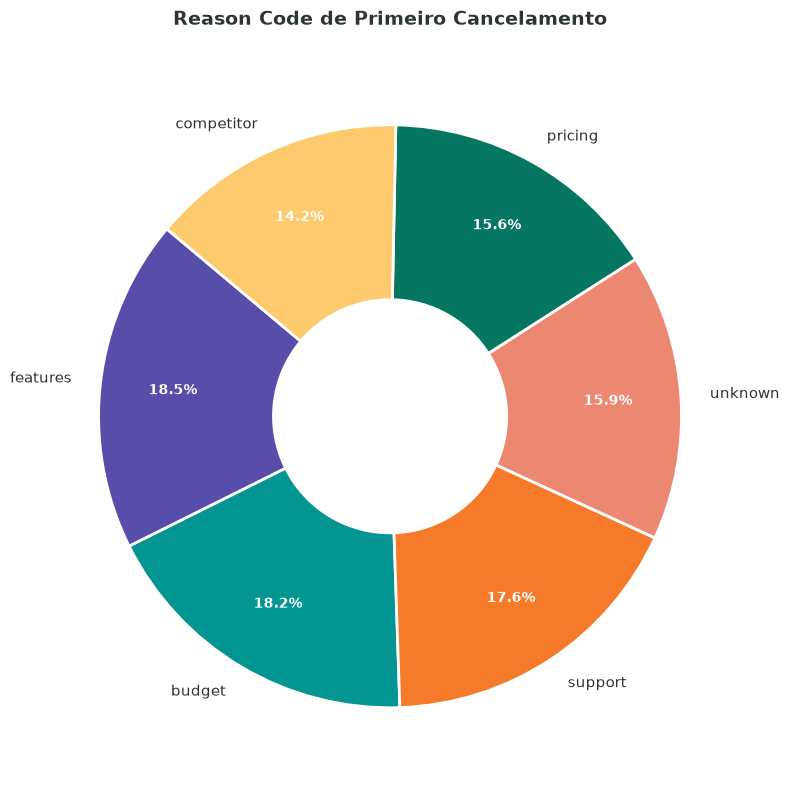

In [16]:
create_churn_reason_pie_chart(reason_counts = first_churn_events["reason_code"].value_counts(), title="Reason Code de Primeiro Cancelamento")

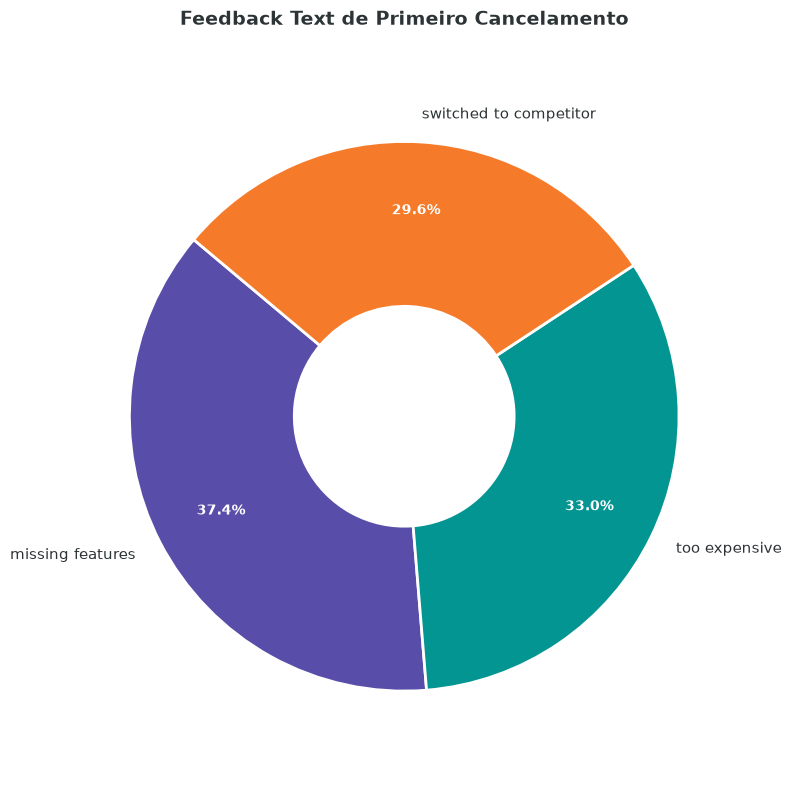

In [17]:
create_churn_reason_pie_chart(reason_counts = first_churn_events["feedback_text"].value_counts(), title = "Feedback Text de Primeiro Cancelamento")

## Text feedback from Reason Code UNKNOWN - 1st churn

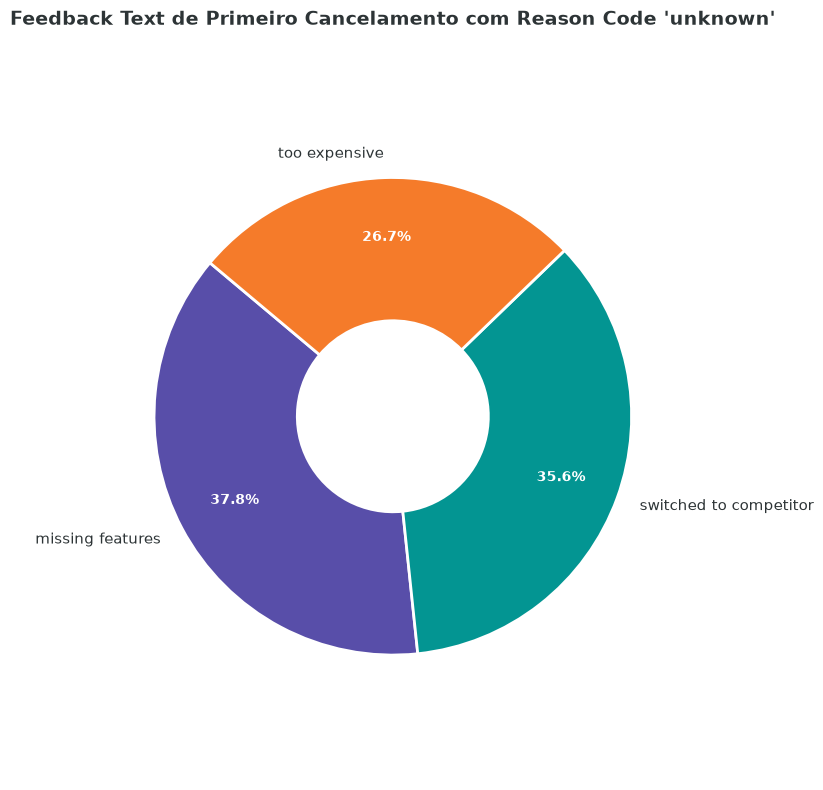

In [18]:
first_churn_unknown = first_churn_events[first_churn_events["reason_code"] == "unknown"]
create_churn_reason_pie_chart(reason_counts = first_churn_unknown["feedback_text"].value_counts(), title = "Feedback Text de Primeiro Cancelamento com Reason Code 'unknown'")

## Accounts churn for the 2nd time and above

In [19]:
second_churn_above = churn_sorted[churn_sorted.groupby("account_id").cumcount() > 0]

second_churn_above.shape

(248, 9)

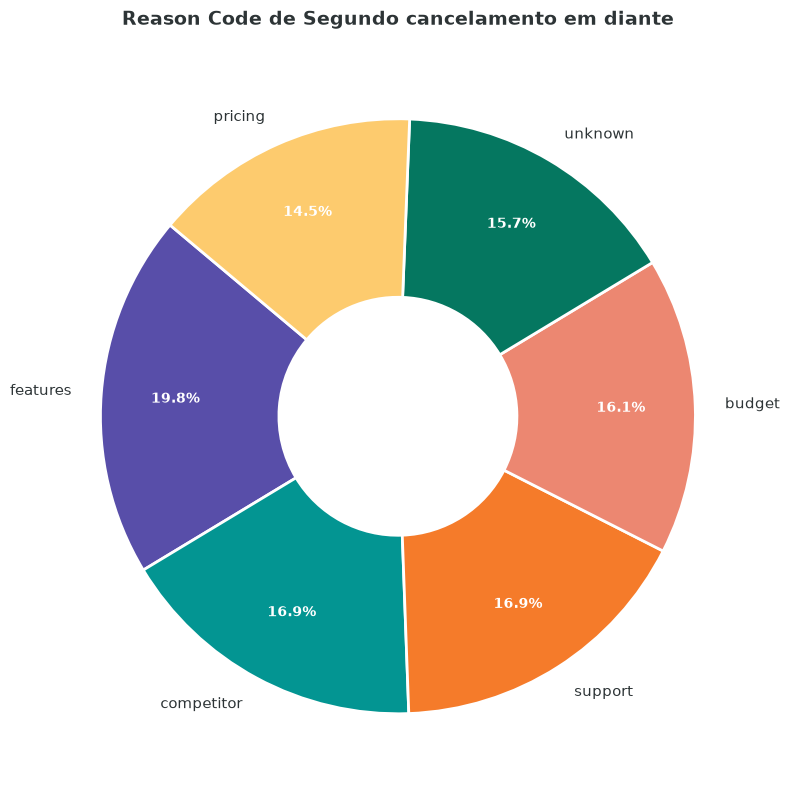

In [20]:
create_churn_reason_pie_chart(reason_counts = second_churn_above["reason_code"].value_counts(), title="Reason Code de Segundo cancelamento em diante")

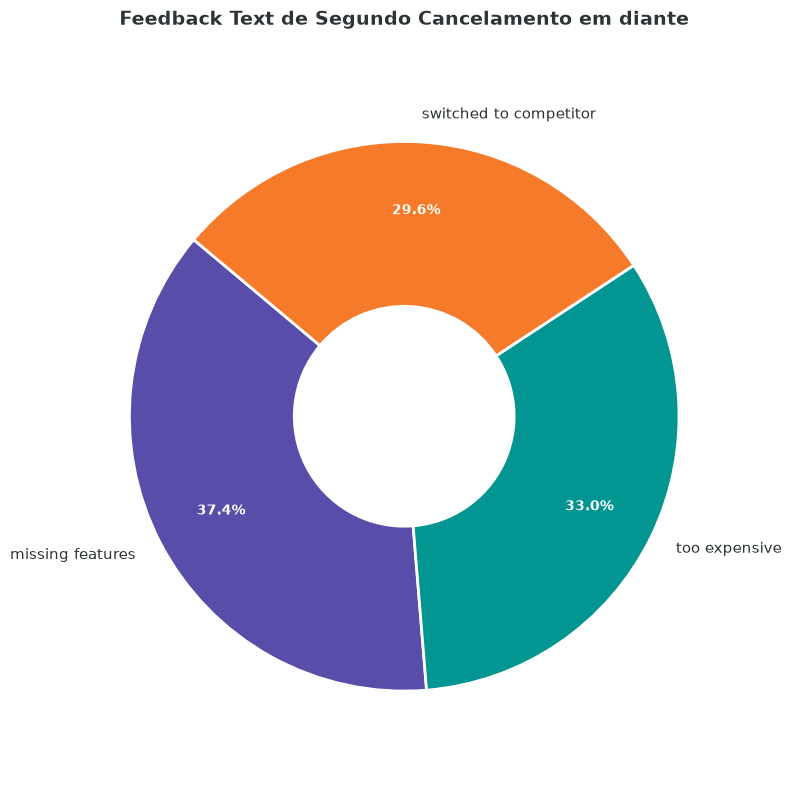

In [21]:
create_churn_reason_pie_chart(reason_counts = first_churn_events["feedback_text"].value_counts(), title = "Feedback Text de Segundo Cancelamento em diante")

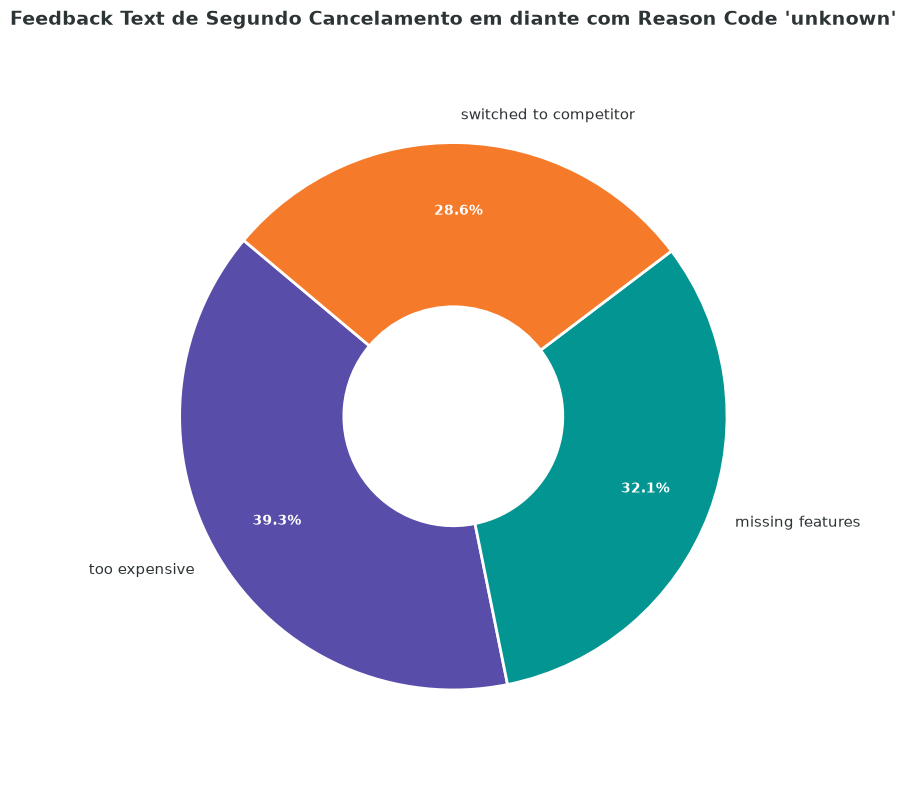

In [22]:
second_churn_above_unknown = second_churn_above[second_churn_above["reason_code"] == "unknown"]
create_churn_reason_pie_chart(reason_counts = second_churn_above_unknown["feedback_text"].value_counts(), title = "Feedback Text de Segundo Cancelamento em diante com Reason Code 'unknown'")

## Tickets analysis

## Scores

* 492/500 have tickets

In [23]:
tickets_df.account_id.unique()

<StringArray>
['A-712f1c', 'A-e43bf7', 'A-0f3e88', 'A-4c56c9', 'A-6f8ad2', 'A-94c3cd',
 'A-2e4581', 'A-72799b', 'A-b179bf', 'A-7cfe77',
 ...
 'A-7f29a7', 'A-fa2041', 'A-054577', 'A-d62e02', 'A-96215d', 'A-0158bb',
 'A-71615e', 'A-b30291', 'A-271f46', 'A-bad8c1']
Length: 492, dtype: str

In [24]:
tickets_df.priority.unique()

<StringArray>
['high', 'urgent', 'medium', 'low']
Length: 4, dtype: str

In [25]:
tickets_df.head(5)

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [26]:
print(tickets_df["satisfaction_score"].unique())
print("Sum of score 3: {}".format(len(tickets_df[tickets_df["satisfaction_score"] == 3])))
print("Sum of score 4: {}".format(len(tickets_df[tickets_df["satisfaction_score"] == 4])))
print("Sum of score 5: {}".format(len(tickets_df[tickets_df["satisfaction_score"] == 5])))
print("Sum of NaN scores: {}".format(len(tickets_df[tickets_df["satisfaction_score"].isnull()])))
print("Shape of tickets_df:", tickets_df.shape)

print("Sum total : {}".format(len(tickets_df[tickets_df["satisfaction_score"].isin([1, 2, 3, 4, 5])])))

[nan  4.  5.  3.]
Sum of score 3: 396
Sum of score 4: 405
Sum of score 5: 374
Sum of NaN scores: 825
Shape of tickets_df: (2000, 9)
Sum total : 1175


In [27]:
import matplotlib.pyplot as plt
import pandas as pd

    
def create_pie_chart(scores_counts, include_nan, title, dict_colors):
    if not include_nan:
        scores_counts = scores_counts.drop("Não Respondeu", errors="ignore")
   
    plt.figure(figsize=(8, 8), facecolor="white")

    wedges, texts, autotexts = plt.pie(
        scores_counts,
        labels=scores_counts.index,
        autopct="%1.1f%%",
        startangle=140,
        colors=[dict_colors.get(x, "#C1C1C1") for x in scores_counts.index],
        pctdistance=0.75,
        wedgeprops=dict(width=0.6, edgecolor="white", linewidth=2),
    )

    plt.setp(autotexts, size=10, weight="bold", color="#2D3436")
    plt.setp(texts, size=11, color="#2D3436")

    plt.title(
        title,
        fontsize=14,
        pad=20,
        weight="bold",
        color="#2D3436",
    )

    plt.axis("equal")
    plt.tight_layout()
    plt.show()

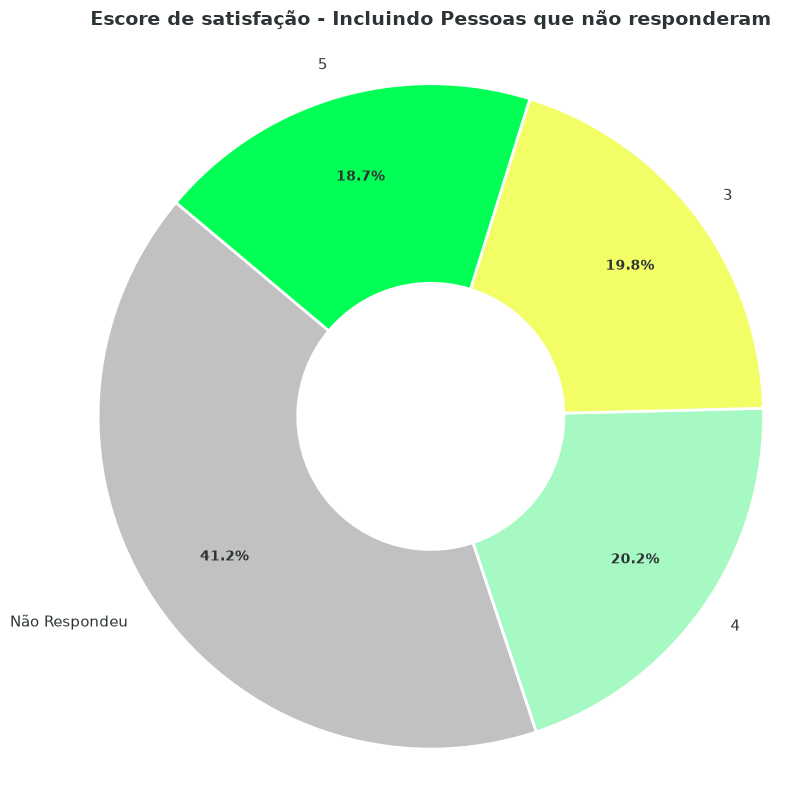

In [28]:
dict_colors = {1: "#FD1313",2: "#FF4500", 3: "#F3FD66", 4: "#A6F9C2", 5: "#02FF56", "Não Respondeu": "#C1C1C1"}
scores = (tickets_df["satisfaction_score"].astype("Int64").astype("object").fillna("Não Respondeu").value_counts())
create_pie_chart(scores, True, "Escore de satisfação - Incluindo Pessoas que não responderam", dict_colors)

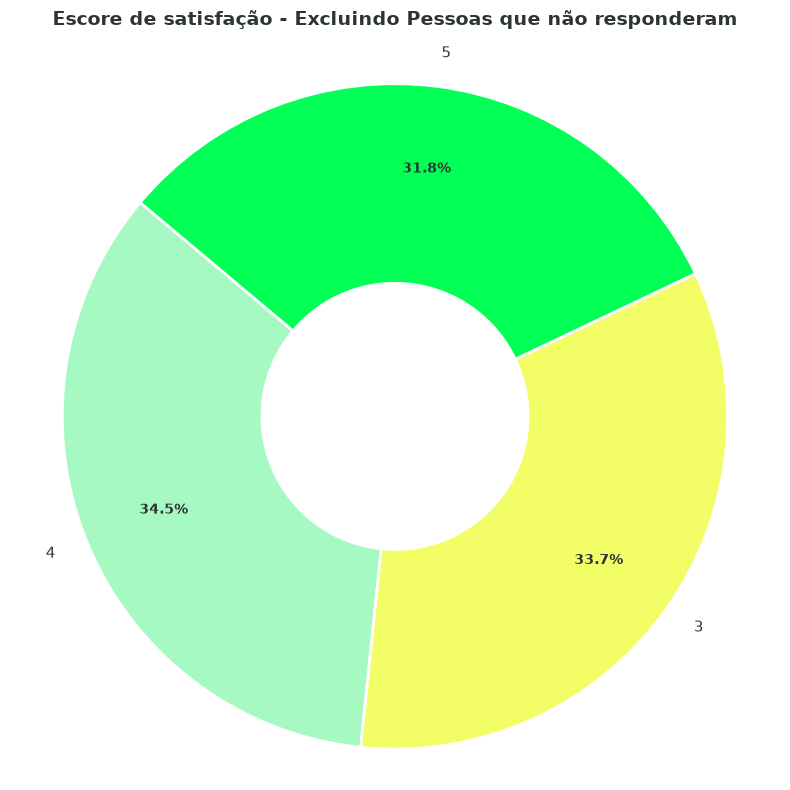

In [29]:
create_pie_chart(scores, False, "Escore de satisfação - Excluindo Pessoas que não responderam", dict_colors)

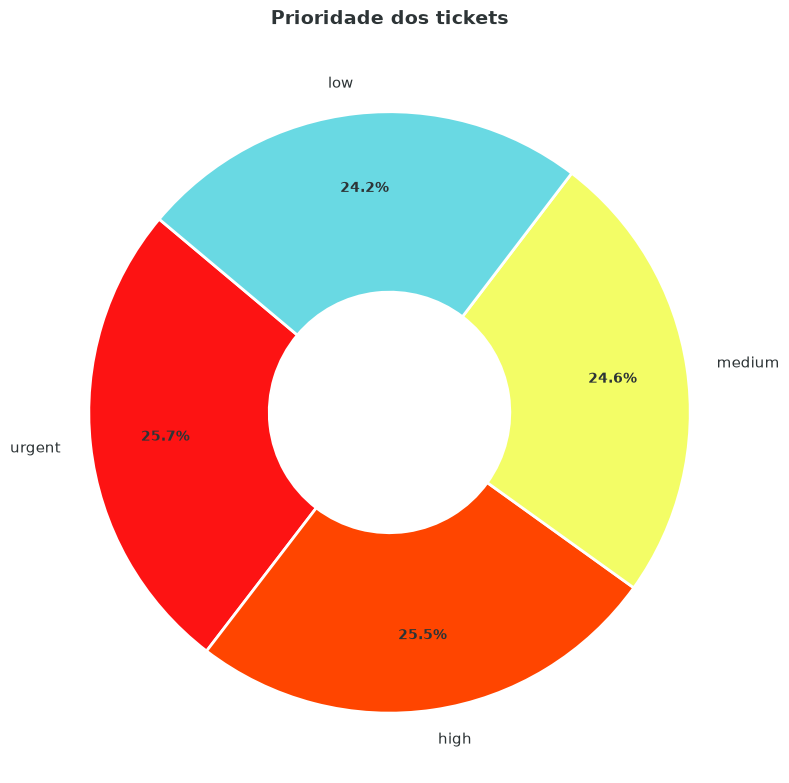

In [30]:
dict_colors = {"urgent": "#FD1313", "high": "#FF4500", "medium": "#F3FD66", "low": "#69D9E3"}
priority = (tickets_df["priority"].value_counts())
create_pie_chart(priority, False, "Prioridade dos tickets", dict_colors)

## Resolution time

In [31]:
import matplotlib.pyplot as plt
import pandas as pd


def create_bars_graphic(df, title):
    bins = [0, 1, 5, 10, 15, 20, float("inf")]
    labels = ["0-1", "1-5", "5-10", "10-15", "15-20", "20+"]

    counts = (
        pd.cut(
            df["resolution_time_hours"],
            bins=bins,
            labels=labels,
            right=False, 
        )
        .value_counts()
        .reindex(labels, fill_value=0)
    )

    # Plot
    plt.figure(figsize=(10, 6), facecolor="white")
    bars = plt.bar(counts.index, counts.values, color="#584EA9", edgecolor="none")

    # Add data values on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.annotate(
            f"{int(height)}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=10,
            weight="bold",
            color="#2D3436",
        )

    plt.title(title, fontsize=14, weight="bold", pad=15, color="#2D3436")
    plt.xlabel("Tempo de resolução (horas)", fontsize=12, weight="bold", color="#2D3436")
    plt.ylabel("Número de Tickets", fontsize=12, weight="bold", color="#2D3436")

    # Clean styling
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()


    

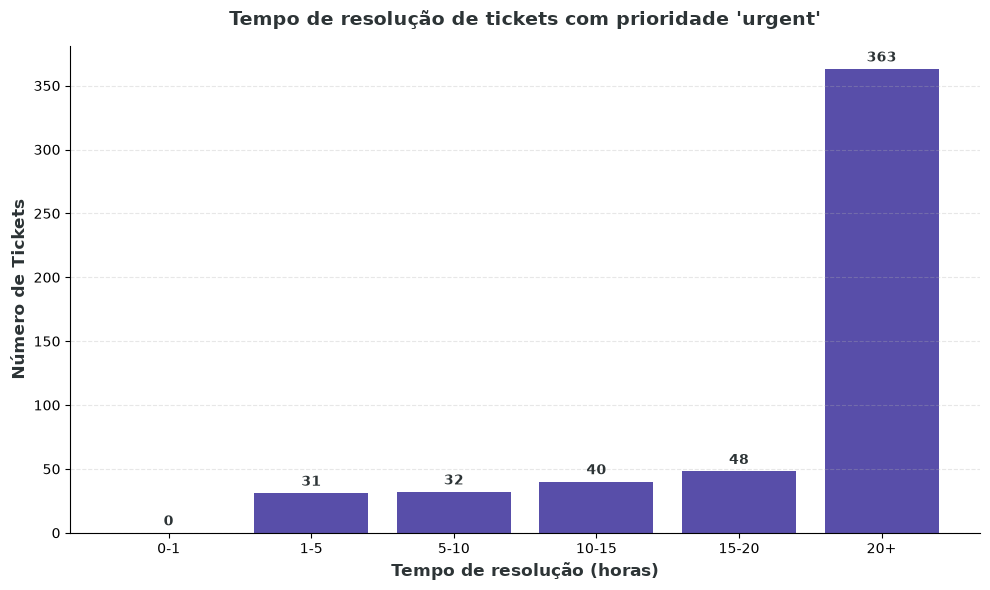

In [32]:
tickets_urgent = tickets_df[tickets_df["priority"] == "urgent"]
create_bars_graphic(tickets_urgent, "Tempo de resolução de tickets com prioridade 'urgent'") 

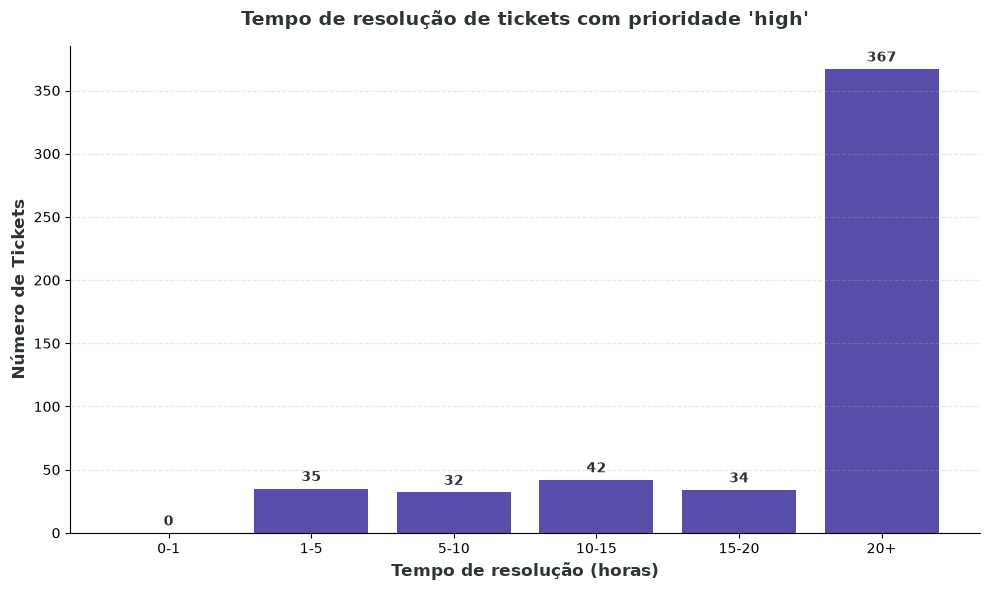

In [33]:
tickets_high = tickets_df[tickets_df["priority"] == "high"]
create_bars_graphic(tickets_high, "Tempo de resolução de tickets com prioridade 'high'") 

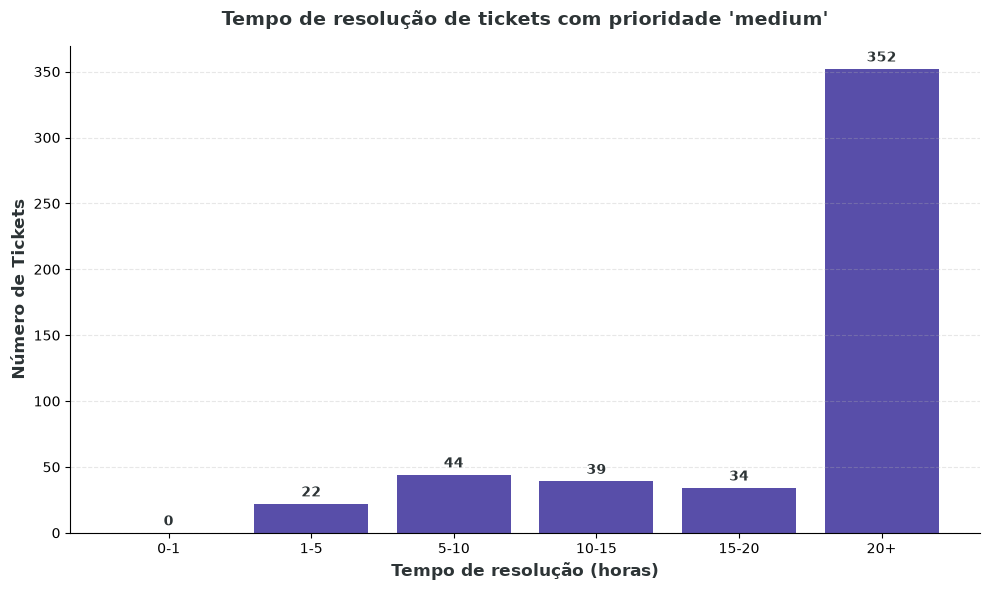

In [34]:
tickets_high = tickets_df[tickets_df["priority"] == "medium"]
create_bars_graphic(tickets_high, "Tempo de resolução de tickets com prioridade 'medium'") 

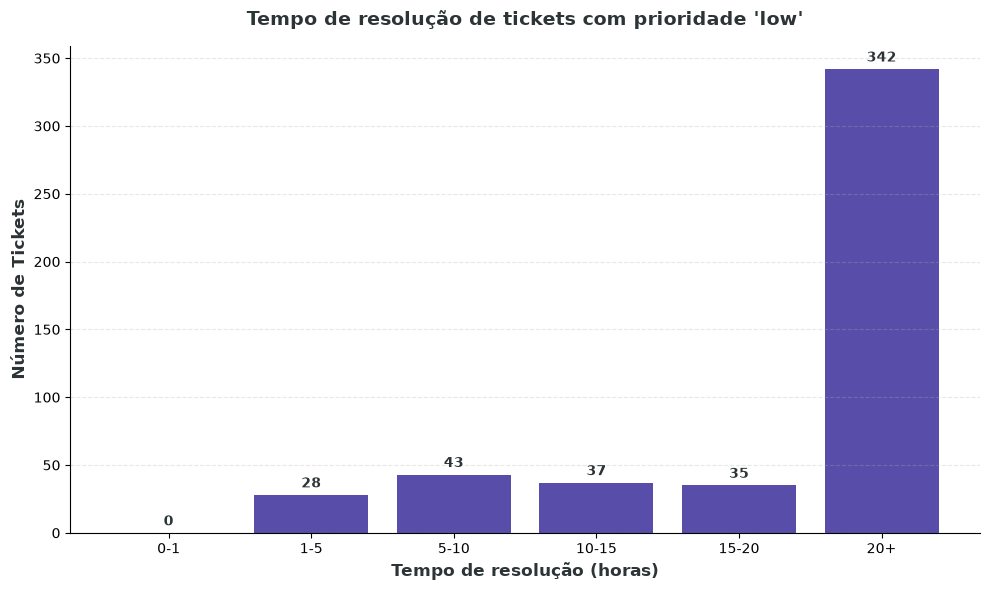

In [35]:
tickets_high = tickets_df[tickets_df["priority"] == "low"]
create_bars_graphic(tickets_high, "Tempo de resolução de tickets com prioridade 'low'") 

# Features

In [36]:
features_df["feature_name"].unique() #40 features

<StringArray>
['feature_20',  'feature_5',  'feature_3', 'feature_40', 'feature_12',
 'feature_14', 'feature_34', 'feature_27', 'feature_18', 'feature_28',
 'feature_36', 'feature_35', 'feature_25',  'feature_4', 'feature_24',
 'feature_37',  'feature_7', 'feature_15', 'feature_30', 'feature_39',
 'feature_19',  'feature_6', 'feature_21',  'feature_1', 'feature_22',
 'feature_38', 'feature_29', 'feature_23', 'feature_31', 'feature_16',
  'feature_9', 'feature_26', 'feature_11', 'feature_10', 'feature_33',
  'feature_8', 'feature_13', 'feature_32', 'feature_17',  'feature_2']
Length: 40, dtype: str

In [37]:
# All features are used kind of equally
features_df["feature_name"].value_counts().sort_values(ascending=False)

feature_name
feature_12    659
feature_32    659
feature_6     655
feature_17    651
feature_34    650
feature_26    649
feature_36    648
feature_31    644
feature_20    643
feature_24    643
feature_38    643
feature_11    643
feature_2     642
feature_15    640
feature_29    640
feature_37    636
feature_22    636
feature_33    635
feature_10    634
feature_39    631
feature_30    629
feature_1     629
feature_4     625
feature_9     624
feature_28    623
feature_16    622
feature_40    621
feature_7     619
feature_25    615
feature_13    612
feature_27    611
feature_14    600
feature_3     598
feature_8     596
feature_21    591
feature_19    589
feature_18    588
feature_35    587
feature_5     577
feature_23    563
Name: count, dtype: int64

In [38]:
print(features_df.shape)
print(tickets_df.shape)

(25000, 8)
(2000, 9)


In [39]:
tickets_urgent.account_id.unique()

<StringArray>
['A-e43bf7', 'A-0f3e88', 'A-2e4581', 'A-b179bf', 'A-7cfe77', 'A-ee42db',
 'A-503d5a', 'A-c9bb3e', 'A-fd7ad3', 'A-bc4d48',
 ...
 'A-1e6fc3', 'A-0cc442', 'A-7f4db3', 'A-87aa7b', 'A-9779ad', 'A-a865bd',
 'A-95b24a', 'A-2b9d3e', 'A-7f6b86', 'A-4c38bc']
Length: 317, dtype: str

#### Merge subscriptions and features

In [40]:
sub = subscriptions_df[["account_id", "subscription_id"]]
print(f"Sub shape: {sub.shape}")
print(f"Features shape: {features_df.shape}") # Features usage!
print(f"Features columns: {features_df.columns}")
feat_sub = pd.merge(features_df, sub, on="subscription_id", how="inner")
print(f"Features sub shape: {feat_sub.shape}")
sub.head()

Sub shape: (5000, 2)
Features shape: (25000, 8)
Features columns: Index(['usage_id', 'subscription_id', 'usage_date', 'feature_name',
       'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature'],
      dtype='str')
Features sub shape: (25000, 9)


,account_id,subscription_id
0,A-3c1a3f,S-8cec59
1,A-9b9fe9,S-0f6f44
2,A-659280,S-51c0d1
3,A-e7a1e2,S-f81687
4,A-ba6516,S-cff5a2


In [41]:
feat_sub.head() # Features usage by account_id and subscription_id

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c


#### Features used by accounts that opened tickets with urgent or high priority

In [42]:
tickets_urgent_high = tickets_df[(tickets_df["priority"] == "urgent") | (tickets_df["priority"] == "high")]

## Filter features used by accounts that opened tickets with priority 'urgent' or 'high'
feat_sub_tickets_filtered = feat_sub[feat_sub["account_id"].isin(tickets_urgent_high["account_id"])]
print(f"Filtered features shape: {feat_sub_tickets_filtered.shape}")

Filtered features shape: (21930, 9)


In [43]:
# tickets_urgent_high
# Recommend to put a column with the features being discussed!

In [44]:
feat_sub_tickets_filtered.value_counts("feature_name").sort_values(ascending=False)
top10_feat_tickets = feat_sub_tickets_filtered.value_counts("feature_name").sort_values(ascending=False).head(10)
top10_feat_tickets

# Fearures used by accounts that opened tickets with priority 'urgent' or 'high'

feature_name
feature_32    589
feature_24    575
feature_36    572
feature_12    571
feature_2     570
feature_26    568
feature_20    567
feature_22    567
feature_34    567
feature_31    566
Name: count, dtype: int64

In [45]:
## Filter features used by accounts that churned
feat_sub_churn_filtered = feat_sub[feat_sub["account_id"].isin(churn_df["account_id"])]
print(feat_sub.shape)
print(feat_sub_churn_filtered.shape)
feat_sub_churn_filtered.head()

(25000, 9)
(17690, 9)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7
5,U-c5692d,S-e958ba,2023-10-31,feature_14,11,4103,0,False,A-417d2f
7,U-a60033,S-4e4ab7,2023-06-05,feature_27,10,5470,0,False,A-eb1312


In [46]:
feat_sub_churn_filtered.value_counts("feature_name").sort_values(ascending=False)
top10_feat_churn = feat_sub_churn_filtered.value_counts("feature_name").sort_values(ascending=False).head(10)
top10_feat_churn

feature_name
feature_12    476
feature_6     475
feature_32    472
feature_34    467
feature_17    464
feature_26    463
feature_31    461
feature_10    460
feature_15    460
feature_24    459
Name: count, dtype: int64

In [47]:
print(f"Top 10 features used by accounts that opened tickets with priority 'urgent' or 'high': {top10_feat_tickets}")

print(f"Top 10 features used by accounts that churned: {top10_feat_churn}")

problem_features = set(top10_feat_tickets.index).intersection(set(top10_feat_churn.index))
print(f"Features that are common to both groups: {problem_features}")

Top 10 features used by accounts that opened tickets with priority 'urgent' or 'high': feature_name
feature_32    589
feature_24    575
feature_36    572
feature_12    571
feature_2     570
feature_26    568
feature_20    567
feature_22    567
feature_34    567
feature_31    566
Name: count, dtype: int64
Top 10 features used by accounts that churned: feature_name
feature_12    476
feature_6     475
feature_32    472
feature_34    467
feature_17    464
feature_26    463
feature_31    461
feature_10    460
feature_15    460
feature_24    459
Name: count, dtype: int64
Features that are common to both groups: {'feature_26', 'feature_31', 'feature_12', 'feature_32', 'feature_24', 'feature_34'}
